In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 1. Download 1 year of daily stock price data for a company (Yahoo Finance).

# We will use Apple (AAPL) as an example.
ticker = "AAPL"
print(f"Downloading 1 year of data for {ticker}...")
data = yf.download(ticker, period="1y")

[*********************100%***********************]  1 of 1 completed


In [5]:
# 2. Set the Date column as DatetimeIndex.

# Note: yf.download automatically returns a DataFrame with 'Date' as the DatetimeIndex.
# However, if 'Date' was a regular column, you would use the following line:
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Ensure the index is flat (yfinance sometimes creates multi-index columns)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

In [6]:
# 3. Calculate 30-day rolling average of closing price.

data['Close_30_MA'] = data['Close'].rolling(window=30).mean()

In [7]:
# 4. Group by month and calculate average volume.
# Converting index to a 'Period' (Year-Month) allows precise monthly grouping
monthly_avg_volume = data['Volume'].groupby(data.index.to_period('M')).mean()
print("\n=== Average Monthly Trading Volume ===")
print(monthly_avg_volume)


=== Average Monthly Trading Volume ===
Date
2025-07    4.941686e+07
2025-08    5.800377e+07
2025-09    6.026364e+07
2025-10    4.770183e+07
2025-11    4.618833e+07
2025-12    4.202404e+07
2026-01    5.200086e+07
2026-02    5.204847e+07
2026-03    4.091071e+07
2026-04    4.321612e+07
2026-05    4.906432e+07
2026-06    6.672239e+07
2026-07    4.715146e+07
Freq: M, Name: Volume, dtype: float64



=== Trading Days with > 5% Movement ===
Price            Close  Daily_Return
Date                                
2025-08-06  212.407349      0.050907
2026-06-25  275.149994     -0.061178


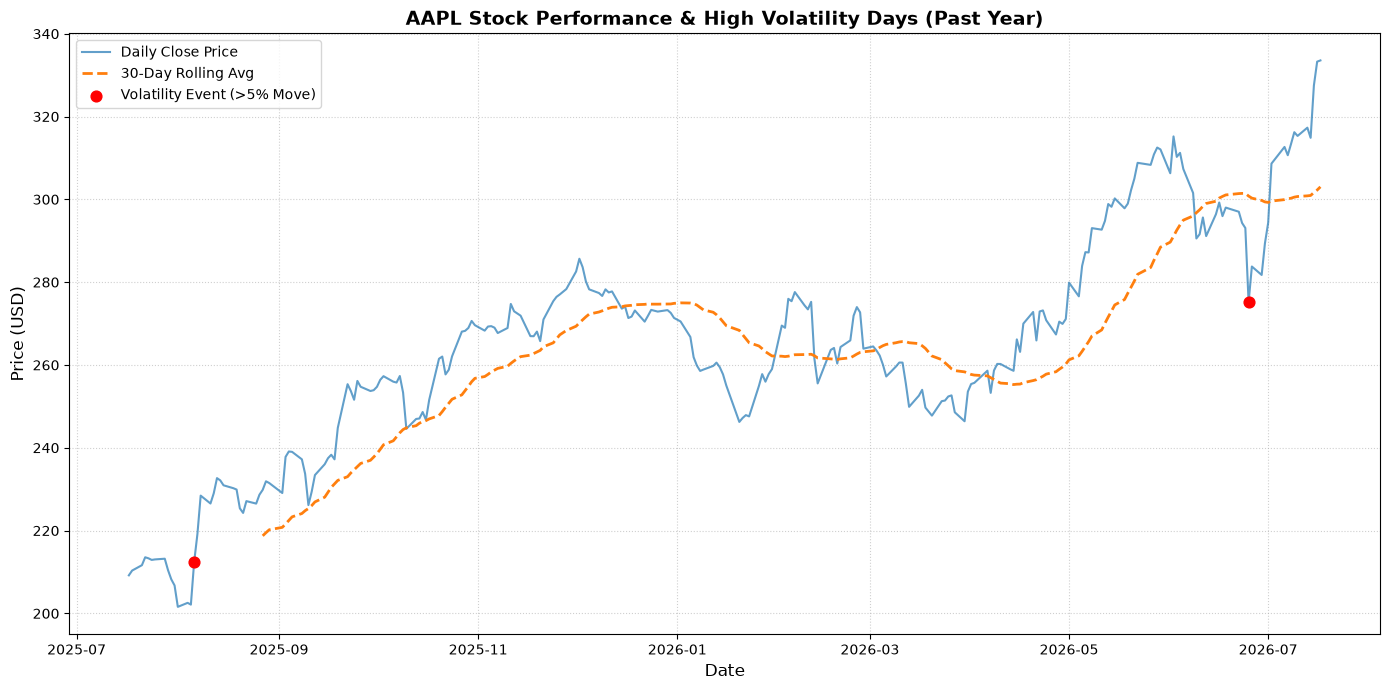

In [8]:
# 5. Challenge: Identify trading days with price movement > 5% and plot them. 

# Price movement is calculated as the daily absolute percentage change
data['Daily_Return'] = data['Close'].pct_change()
significant_days = data[data['Daily_Return'].abs() > 0.05]

print("\n=== Trading Days with > 5% Movement ===")
if not significant_days.empty:
    print(significant_days[['Close', 'Daily_Return']])
else:
    print("No days found with > 5% price movement in this period.")

# --- Plotting the Results ---
plt.figure(figsize=(14, 7))

# Plot closing price and rolling average
plt.plot(data.index, data['Close'], label='Daily Close Price', color='#1f77b4', alpha=0.7, linewidth=1.5)
plt.plot(data.index, data['Close_30_MA'], label='30-Day Rolling Avg', color='#ff7f0e', linestyle='--', linewidth=2)

# Scatter plot to overlay the significant days (>5% movement)
if not significant_days.empty:
    plt.scatter(significant_days.index, significant_days['Close'], color='red', 
                label='Volatility Event (>5% Move)', marker='o', s=60, zorder=5)

# Formatting the visual
plt.title(f'{ticker} Stock Performance & High Volatility Days (Past Year)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()